## -- Stage 1: Load .mat files and apply a 50:1 imbalance to the raw signals (before segmentation).
## -- Stage 2: Segment signals into overlapping blocks (1600 samples, 320 interval) and one-hot encode labels for 10 classes.
## -- Stage 3: Perform an 80:20 class-wise time-based train-test split.

## Set Up Environment 

In [1]:
import tensorflow as tf
import numpy as np
import random
import os

# Set a fixed seed value for reproducibility
SEED = 1
random.seed(SEED)            # Python random module
np.random.seed(SEED)         # NumPy
tf.random.set_seed(SEED)     # TensorFlow

# Enforce deterministic behavior for GPU operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # Ensure deterministic execution
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Deterministic cuDNN algorithms

# Control GPU memory allocation (prevents TensorFlow from using all GPU memory)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)  # Enable memory growth

# Restrict parallelism (ensures consistent execution order)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

import os
import scipy.io 
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
from sklearn.metrics import f1_score, classification_report
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    log_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt

## Read CWRU Bearing Data (Load - 2HP)
# --- Stage 1: Load CWRU Bearing Data ---

In [2]:
def load_and_imbalance_cwru_data(folder_path, imbalance_ratio=50):
    """
    Load CWRU bearing data from .mat files and apply imbalance to raw signals.

    Args:
        folder_path (str): Path to the directory containing .mat files.
        imbalance_ratio (int): Ratio of normal to fault signal lengths (default: 50).

    Returns:
        pd.DataFrame: DataFrame with columns 'Condition', 'Fault Size (mm)', 'Fault Label', 'Signal'.
    """
    data_dict = {
        'Condition': [],
        'Fault Size (mm)': [],
        'Fault Label': [],
        'Signal': []
    }

    conditions = [
        ('99.mat', 'Normal', 0, 0),
        ('124.mat', 'RE (Rolling element)', 0.18, 1),
        ('111.mat', 'IR (Inner ring)', 0.18, 2),
        ('137.mat', 'OR (Outer ring)', 0.18, 3),
        ('191.mat', 'RE (Rolling element)', 0.36, 4),
        ('176.mat', 'IR (Inner ring)', 0.36, 5),
        ('203.mat', 'OR (Outer ring)', 0.36, 6),
        ('228.mat', 'RE (Rolling element)', 0.54, 7),
        ('215.mat', 'IR (Inner ring)', 0.54, 8),
        ('240.mat', 'OR (Outer ring)', 0.54, 9)
    ]

    # Load normal signal to determine target length
    normal_signal = None
    for file_name, condition, fault_size, fault_label in conditions:
        if fault_label == 0:  # Normal class
            file_path = os.path.join(folder_path, file_name)
            file_number = file_name.split(".")[0].zfill(3)
            normal_signal = scipy.io.loadmat(file_path)[f'X{file_number}_DE_time'].flatten()
            break

    normal_length = len(normal_signal)
    target_fault_length = max(1000, normal_length // imbalance_ratio)  # Ensure minimum length for segmentation

    for file_name, condition, fault_size, fault_label in conditions:
        file_path = os.path.join(folder_path, file_name)
        file_number = file_name.split(".")[0].zfill(3)
        signal = scipy.io.loadmat(file_path)[f'X{file_number}_DE_time'].flatten()
        
        # Apply imbalance by subsampling fault signals
        if fault_label != 0:  # Fault classes
            if len(signal) > target_fault_length:
                signal = signal[:target_fault_length]
        
        data_dict['Condition'].append(condition)
        data_dict['Fault Size (mm)'].append(fault_size)
        data_dict['Fault Label'].append(fault_label)
        data_dict['Signal'].append(signal)

    df = pd.DataFrame(data_dict)
    print("\nRaw Signal Lengths After Imbalance Preprocessing:")
    for class_idx, row in df.iterrows():
        print(f"Class {class_idx} (Fault Label: {row['Fault Label']}, {row['Condition']}): {len(row['Signal'])} data points")

    return df

## Data Processing and Feature Extraction with Imbalanced Data

# --- Stage 2: Windowing with Overlap ---


In [3]:
def extract_segments(data, samples_per_block, interval_length, ignore_points=0):
    """
    Extract segments from data using vectorized indexing.

    Args:
        data (np.ndarray): Input signal data.
        samples_per_block (int): Length of each segment.
        interval_length (int): Step size between segment starts.
        ignore_points (int): Points to ignore at start and end.

    Returns:
        np.ndarray: Array of shape (n_segments, samples_per_block).
    """
    data = np.asarray(data).flatten()
    adjusted_length = len(data) - 2 * ignore_points
    n_segments = max(0, (adjusted_length - samples_per_block) // interval_length + 1)
    if n_segments == 0:
        return np.empty((0, samples_per_block), dtype=data.dtype)

    start_indices = ignore_points + np.arange(n_segments) * interval_length
    indices = start_indices[:, None] + np.arange(samples_per_block)
    return data[indices]

In [4]:
def segment_signals(df, samples_per_block, interval_length, n_classes):
    """
    Segment signals into overlapping blocks and one-hot encode labels.

    Args:
        df (pd.DataFrame): DataFrame with 'Signal' and 'Fault Label' columns.
        samples_per_block (int): Number of samples per segment.
        interval_length (int): Step size between segments.
        n_classes (int): Number of fault classes.

    Returns:
        tuple: (segment_list, one_hot_labels, integer_labels)
            - segment_list: List of segment arrays per class.
            - one_hot_labels: List of one-hot encoded label arrays.
            - integer_labels: List of integer label arrays.
    """
    segment_list = []
    one_hot_labels = []
    integer_labels = []

    for class_idx, row in df.iterrows():
        signal = row['Signal']
        fault_label = row['Fault Label']
        condition = row['Condition']

        segments = extract_segments(signal, samples_per_block, interval_length)
        n_segments = segments.shape[0]

        print(f"\nClass {class_idx} (Fault Label: {fault_label}, {condition}):")
        print(f"Segments: {n_segments} segments")
        print(f"Sample data (first 5 elements): {segments[0][:5] if n_segments > 0 else 'Empty'}")

        if n_segments > 0:
            one_hot = np.zeros((n_segments, n_classes))
            one_hot[:, class_idx] = 1
            labels = np.full((n_segments, 1), class_idx)

            segment_list.append(segments)
            one_hot_labels.append(one_hot)
            integer_labels.append(labels)

    return segment_list, one_hot_labels, integer_labels

# --- Stage 3: Imbalance

In [5]:
def preprocess_train_for_imbalance(segments, labels, imbalance_ratio=50):
    """
    Apply imbalance preprocessing to sampled training segments to achieve specified ratio.

    Args:
        segments (List[np.ndarray]): List of sampled segment arrays (n_segments, samples_per_block).
        labels (List[int]): List of corresponding fault labels.
        imbalance_ratio (int): Ratio of normal to fault segments (default: 50).

    Returns:
        List[np.ndarray]: List of preprocessed training segment arrays.
    """
    processed_segments = []
    normal_segments = next((seg for seg, lbl in zip(segments, labels) if lbl == 0), np.array([]))
    n_normal_segments = normal_segments.shape[0]
    target_fault_segments = max(1, n_normal_segments // imbalance_ratio)

    for segment_array, fault_label in zip(segments, labels):
        n_segments = segment_array.shape[0]
        if n_segments == 0:
            print(f"No segments available for Fault Label {fault_label}. Skipping.")
            processed_segments.append(np.array([]).reshape(0, segment_array.shape[1]))
            continue
        target = n_normal_segments if fault_label == 0 else target_fault_segments
        selected_segments = segment_array[:min(target, n_segments)]
        processed_segments.append(selected_segments)
    return processed_segments

# --- Time-Based Train-Test Split

In [6]:
def time_train_test_split(segment_list, one_hot_labels, integer_labels, df, train_ratio=0.8, n_classes=10):
    """
    Perform time-based class-wise train-test split.

    Args:
        segment_list (List[np.ndarray]): List of segment arrays per class.
        one_hot_labels (List[np.ndarray]): List of one-hot encoded label arrays.
        integer_labels (List[np.ndarray]): List of integer label arrays.
        df (pd.DataFrame): DataFrame with 'Signal', 'Fault Label', 'Condition'.
        train_ratio (float): Fraction of data for training.
        n_classes (int): Number of classes.

    Returns:
        tuple: (X_train, X_test, Y_train, Y_test, y_train, y_test)
            - X_ are 4D arrays for CNN (n_samples, 40, 40, 1).
            - Y_ are one-hot labels (n_samples, n_classes).
            - y_ are integer labels (n_samples, 1).
    """
    X_train_list, X_test_list = [], []
    Y_train_list, Y_test_list = [], []
    y_train_list, y_test_list = [], []

    post_split_train_lengths = []
    post_split_test_lengths = []

    fault_labels = df['Fault Label'].values
    conditions = df['Condition'].values

    for class_idx, (signal, segments, one_hot, integer, fault_label, condition) in enumerate(
        zip(df['Signal'], segment_list, one_hot_labels, integer_labels, fault_labels, conditions)
    ):
        n_segments = segments.shape[0]
        train_size = int(n_segments * train_ratio)
        train_segments = segments[:train_size]
        test_segments = segments[train_size:]

        post_split_train_lengths.append((class_idx, fault_label, condition, train_segments.shape[0]))
        post_split_test_lengths.append((class_idx, fault_label, condition, test_segments.shape[0]))

        if train_segments.shape[0] > 0:
            train_one_hot = one_hot[:train_size]
            train_labels = integer[:train_size]
            X_train_list.append(train_segments)
            Y_train_list.append(train_one_hot)
            y_train_list.append(train_labels)

        if test_segments.shape[0] > 0:
            test_one_hot = one_hot[train_size:]
            test_labels = integer[train_size:]
            X_test_list.append(test_segments)
            Y_test_list.append(test_one_hot)
            y_test_list.append(test_labels)

        print(f"\nClass {class_idx} (Fault Label: {fault_label}, {condition}):")
        print(f"Train segments (post-split): {train_segments.shape[0]} segments")
        print(f"Test segments (post-split): {test_segments.shape[0]} segments")
        print(f"Sample train data (first 5 elements): {train_segments[0][:5] if train_segments.shape[0] > 0 else 'Empty'}")
        print(f"Sample test data (first 5 elements): {test_segments[0][:5] if test_segments.shape[0] > 0 else 'Empty'}")

    print("\nTraining Segments After Split:")
    for class_idx, fault_label, condition, segment_count in post_split_train_lengths:
        print(f"Class {class_idx} (Fault Label: {fault_label}, {condition}): {segment_count} segments")

    print("\nTest Segments After Split:")
    for class_idx, fault_label, condition, segment_count in post_split_test_lengths:
        print(f"Class {class_idx} (Fault Label: {fault_label}, {condition}): {segment_count} segments")

    X_train = np.vstack(X_train_list) if X_train_list else np.empty((0, 1600))
    X_test = np.vstack(X_test_list) if X_test_list else np.empty((0, 1600))
    Y_train = np.vstack(Y_train_list) if Y_train_list else np.empty((0, n_classes))
    Y_test = np.vstack(Y_test_list) if Y_test_list else np.empty((0, n_classes))
    y_train = np.vstack(y_train_list) if y_train_list else np.empty((0, 1))
    y_test = np.vstack(y_test_list) if y_test_list else np.empty((0, 1))

    X_2D_train = X_train.reshape(-1, 40, 40, 1) if X_train.size > 0 else np.empty((0, 40, 40, 1))
    X_2D_test = X_test.reshape(-1, 40, 40, 1) if X_test.size > 0 else np.empty((0, 40, 40, 1))

    print(f"\nFinal X_train shape: {X_2D_train.shape}")
    print(f"Sample X_train values (first 5 elements): {X_train[0][:5] if X_train.size > 0 else 'Empty'}")
    print(f"Final Y_train shape: {Y_train.shape}")
    print(f"Sample Y_train values (first 5): {Y_train[:5] if Y_train.size > 0 else 'Empty'}")
    print(f"Final y_train shape: {y_train.shape}")
    print(f"Sample y_train values (first 5): {y_train[:5] if y_train.size > 0 else 'Empty'}")
    print(f"\nFinal X_test shape: {X_2D_test.shape}")
    print(f"Sample X_test values (first 5 elements): {X_test[0][:5] if X_test.size > 0 else 'Empty'}")
    print(f"Final Y_test shape: {Y_test.shape}")
    print(f"Sample Y_test values (first 5): {Y_test[:5] if Y_test.size > 0 else 'Empty'}")
    print(f"Final y_test shape: {y_test.shape}")
    print(f"Sample y_test values (first 5): {y_test[:5] if y_test.size > 0 else 'Empty'}")

    return X_2D_train, X_2D_test, Y_train, Y_test, y_train, y_test


In [7]:
# --- Execution ---
folder_path = './CWRU_BearingData_Load_2HP'
interval_length = 320
samples_per_block = 1600
n_classes = 10
train_ratio = 0.8
imbalance_ratio = 50

# Stage 1: Load and apply imbalance
df = load_and_imbalance_cwru_data(folder_path, imbalance_ratio)

# Stage 2: Segment signals
segment_list, one_hot_labels, integer_labels = segment_signals(df, samples_per_block, interval_length, n_classes)

# Stage 3: Train-test split
X_2D_train, X_2D_test, Y_train, Y_test, y_label_train, y_label_test = time_train_test_split(
    segment_list, one_hot_labels, integer_labels, df, train_ratio, n_classes
)


Raw Signal Lengths After Imbalance Preprocessing:
Class 0 (Fault Label: 0, Normal): 485063 data points
Class 1 (Fault Label: 1, RE (Rolling element)): 9701 data points
Class 2 (Fault Label: 2, IR (Inner ring)): 9701 data points
Class 3 (Fault Label: 3, OR (Outer ring)): 9701 data points
Class 4 (Fault Label: 4, RE (Rolling element)): 9701 data points
Class 5 (Fault Label: 5, IR (Inner ring)): 9701 data points
Class 6 (Fault Label: 6, OR (Outer ring)): 9701 data points
Class 7 (Fault Label: 7, RE (Rolling element)): 9701 data points
Class 8 (Fault Label: 8, IR (Inner ring)): 9701 data points
Class 9 (Fault Label: 9, OR (Outer ring)): 9701 data points

Class 0 (Fault Label: 0, Normal):
Segments: 1511 segments
Sample data (first 5 elements): [ 0.06425354  0.06300185 -0.00438092 -0.03588185 -0.02399077]

Class 1 (Fault Label: 1, RE (Rolling element)):
Segments: 26 segments
Sample data (first 5 elements): [0.09992677 0.14164985 0.17836615 0.19463815 0.16876985]

Class 2 (Fault Label: 2, IR

## Multiclass Classification CNN Model Training with Imbalanced Data


In [8]:
import numpy as np
import pandas as pd

# Condition mapping
condition_map = {
    0: "Normal",
    1: "RE 0.18",
    2: "IR 0.18",
    3: "OR 0.18",
    4: "RE 0.36",
    5: "IR 0.36",
    6: "OR 0.36",
    7: "RE 0.54",
    8: "IR 0.54",
    9: "OR 0.54"
}

# X_train distribution (using Y_train)
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique],
    'Blocks': counts
})
print("Blocks per class in X_train:")
print(df_train_orig.to_string(index=False))

# Train set distribution (using Y_train, same as above since no additional split)
train_classes = np.argmax(Y_train, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_train],
    'Blocks': counts_train
})
print("\nX_train_split and Y_train distribution:")
print(df_train.to_string(index=False))

# Test set distribution (using Y_test)
test_classes = np.argmax(Y_test, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_test],
    'Blocks': counts_test
})
print("\nX_test_split and Y_test distribution:")
print(df_test.to_string(index=False))

# y_train_split and y_test_split (same as Y_train and Y_test distributions)
print("\ny_train_split distribution (assumed):")
print(df_train.to_string(index=False))
print("\ny_test_split distribution (assumed):")
print(df_test.to_string(index=False))

Blocks per class in X_train:
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

X_train_split and Y_train distribution:
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

X_test_split and Y_test distribution:
Condition  Blocks
   Normal     303
  RE 0.18       6
  IR 0.18       6
  OR 0.18       6
  RE 0.36       6
  IR 0.36       6
  OR 0.36       6
  RE 0.54       6
  IR 0.54       6
  OR 0.54       6

y_train_split distribution (assumed):
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

y_test_split distribution (assumed):
Condition  Blocks
   N

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
print(f"X_2D_train shape: {X_2D_train.shape}")  # Expected: (num_samples, 1600, 1)
print(f"X_2D_test shape: {X_2D_test.shape}")    # Expected: (num_samples, 1600, 1)
input_shape = (40,40,1)   # Reshaped input


class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()

    def CreateModel(self):
        model = Sequential([
            # Input shape: (40, 40, 1)
            Conv2D(32, (3, 3), activation='relu', input_shape=(40, 40, 1), padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Conv2D(32, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Conv2D(64, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Conv2D(64, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Conv2D(128, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Conv2D(128, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Flatten(),
            layers.Dense(100),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dropout(0.5),
            layers.Dense(96),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dense(10, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        return model

X_2D_train shape: (1388, 40, 40, 1)
X_2D_test shape: (357, 40, 40, 1)


In [10]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential, load_model
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, balanced_accuracy_score

# Condition mapping
condition_map = {
    0: "Normal",
    1: "RE 0.18",
    2: "IR 0.18",
    3: "OR 0.18",
    4: "RE 0.36",
    5: "IR 0.36",
    6: "OR 0.36",
    7: "RE 0.54",
    8: "IR 0.54",
    9: "OR 0.54"
}

# Training with k-fold validation
foldername = "CNN1D_results/Imbalanced-Ratio-BatchNorm/"
kSplits = 5
accuracy_1D = []
precision_1D = []
recall_1D = []
f1_1D = []
log_loss_1D = []
balanced_accuracy_1D = []
accuracy_1D_test = []
precision_1D_test = []
recall_1D_test = []
f1_1D_test = []
log_loss_1D_test = []
balanced_accuracy_1D_test = []

# Initialize arrays for validation predictions across folds
n_train_samples = Y_train.shape[0]
pred_all_val = np.zeros((n_train_samples, 10))  # Store validation predictions
y_val_true = np.zeros((n_train_samples, 10))    # Store true validation labels
kfold_test_len = []                             # Store size of each validation fold
fl1 = 0

early_stop = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
kfold = StratifiedKFold(n_splits=kSplits, random_state=42, shuffle=True)

# Train the model with k-fold cross-validation
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_2D_train, y_label_train.flatten())):
    checkpoint_filepath = foldername + f"best_model_fold_{fold+1}.h5"
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    Classification_2D = CNN_2D()
    history = Classification_2D.model.fit(
        X_2D_train[train_idx], Y_train[train_idx],
        validation_data=(X_2D_train[val_idx], Y_train[val_idx]),
        epochs=200,
        verbose=1,
        callbacks=[checkpoint, early_stop]
    )
    print(f"Best model saved at: {checkpoint_filepath}")
    CNN_2D_best_model = load_model(checkpoint_filepath)
    print("Best model loaded successfully!")

    # Store validation predictions
    fl2 = fl1 + len(val_idx)
    pred_all_val[fl1:fl2, :] = CNN_2D_best_model.predict(X_2D_train[val_idx])
    y_val_true[fl1:fl2, :] = Y_train[val_idx]
    kfold_test_len.append(fl2 - fl1)
    fl1 = fl2

    # Train set metrics (for the current fold's training data)
    y_pred_proba_train = CNN_2D_best_model.predict(X_2D_train[train_idx])
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(Y_train[train_idx], axis=1)

    accuracy_1D.append(accuracy_score(y_true_train, y_pred_train))
    precision_1D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_1D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_1D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_1D.append(log_loss(Y_train[train_idx], y_pred_proba_train))
    balanced_accuracy_1D.append(balanced_accuracy_score(y_true_train, y_pred_train))

    # Test set metrics
    y_pred_proba_test = CNN_2D_best_model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(Y_test, axis=1)

    accuracy_1D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_1D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_1D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_1D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    log_loss_1D_test.append(log_loss(Y_test, y_pred_proba_test))
    balanced_accuracy_1D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

# Print average metrics across folds
print("\nAverage Training Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D):.4f} ± {np.std(accuracy_1D):.4f}")
print(f"Precision: {np.mean(precision_1D):.4f} ± {np.std(precision_1D):.4f}")
print(f"Recall: {np.mean(recall_1D):.4f} ± {np.std(recall_1D):.4f}")
print(f"F1 Score: {np.mean(f1_1D):.4f} ± {np.std(f1_1D):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D):.4f} ± {np.std(log_loss_1D):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D):.4f} ± {np.std(balanced_accuracy_1D):.4f}")

print("\nAverage Test Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D_test):.4f} ± {np.std(accuracy_1D_test):.4f}")
print(f"Precision: {np.mean(precision_1D_test):.4f} ± {np.std(precision_1D_test):.4f}")
print(f"Recall: {np.mean(recall_1D_test):.4f} ± {np.std(recall_1D_test):.4f}")
print(f"F1 Score: {np.mean(f1_1D_test):.4f} ± {np.std(f1_1D_test):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D_test):.4f} ± {np.std(log_loss_1D_test):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D_test):.4f} ± {np.std(balanced_accuracy_1D_test):.4f}")

# Distribution printing (from previous request)
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique],
    'Blocks': counts
})
print("\nBlocks per class in X_train:")
print(df_train_orig.to_string(index=False))

train_classes = np.argmax(Y_train, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_train],
    'Blocks': counts_train
})
print("\nX_train_split and Y_train distribution:")
print(df_train.to_string(index=False))

test_classes = np.argmax(Y_test, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_test],
    'Blocks': counts_test
})
print("\nX_test_split and Y_test distribution:")
print(df_test.to_string(index=False))

print("\ny_train_split distribution (assumed):")
print(df_train.to_string(index=False))
print("\ny_test_split distribution (assumed):")
print(df_test.to_string(index=False))

/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200


2025-07-01 22:59:42.344849: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-07-01 22:59:42.346074: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.7512 - loss: 1.7546

2025-07-01 22:59:57.125625: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-07-01 22:59:57.125981: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

...

35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 341ms/step - accuracy: 0.9829 - loss: 0.0555 - val_accuracy: 0.9784 - val_loss: 0.0748
Epoch 32/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9833 - loss: 0.0589
Epoch 32: val_accuracy did not improve from 0.97842
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 326ms/step - accuracy: 0.9835 - loss: 0.0586 - val_accuracy: 0.9712 - val_loss: 0.0758
Epoch 33/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.9883 - loss: 0.0353
Epoch 41: val_accuracy improved from 0.98201 to 0.98921, saving model to CNN1D_results/Imbalanced-Ratio-BatchNorm/best_model_fold_1.h5


35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 349ms/step - accuracy: 0.9884 - loss: 0.0351 - val_accuracy: 0.9892 - val_loss: 0.1235
Epoch 42/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.9969 - loss: 0.0244
Epoch 42: val_accuracy did not improve from 0.98921
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 343ms/step - accuracy: 0.9969 - loss: 0.0245 - val_accuracy: 0.9820 - val_loss: 0.1190
Epoch 43/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9885 - loss: 0.0260
Epoch 43: val_accuracy did not improve from 0.98921
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 470ms/step - accuracy: 0.9886 - loss: 0.0260 - val_accuracy: 0.7014 - val_loss: 0.7072
Epoch 44/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9949 - loss: 0.0292
Epoch 44: val_accuracy did not improve from 0.98921
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 378ms/step - accuracy: 0.9950 - loss: 0.0290 - val_accuracy: 0.9856 - val_loss: 0.0382
Epoch 45/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9975 - loss: 0.0251
Epoch 45: val_accura

35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 318ms/step - accuracy: 0.9968 - loss: 0.0214 - val_accuracy: 0.9928 - val_loss: 0.0266
Epoch 54/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9988 - loss: 0.0078
Epoch 54: val_accuracy did not improve from 0.99281
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 354ms/step - accuracy: 0.9988 - loss: 0.0078 - val_accuracy: 0.9892 - val_loss: 0.0312
Epoch 55/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9980 - loss: 0.0123
Epoch 55: val_accuracy did not improve from 0.99281
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 346ms/step - accuracy: 0.9980 - loss: 0.0123 - val_accuracy: 0.9784 - val_loss: 0.0767
Epoch 56/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9996 - loss: 0.0104
Epoch 56: val_accuracy did not improve from 0.99281
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 331ms/step - accuracy: 0.9995 - loss: 0.0103 - val_accuracy: 0.9892 - val_loss: 0.0266
Epoch 57/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 1.0000 - loss: 0.0073
Epoch 57: val_accura

35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 325ms/step - accuracy: 0.9986 - loss: 0.0037 - val_accuracy: 0.9964 - val_loss: 0.0134
Epoch 82/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 1.0000 - loss: 0.0030
Epoch 82: val_accuracy did not improve from 0.99640
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 359ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9892 - val_loss: 0.0295
Epoch 83/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9991 - loss: 0.0033
Epoch 83: val_accuracy did not improve from 0.99640
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 317ms/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 0.9676 - val_loss: 0.1717
Epoch 84/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9962 - loss: 0.0092
Epoch 84: val_accuracy did not improve from 0.99640
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 320ms/step - accuracy: 0.9962 - loss: 0.0092 - val_accuracy: 0.9676 - val_loss: 0.1298
Epoch 85/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9953 - loss: 0.0131
Epoch 85: val_accura

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Multiclass Classification CNN Model Evaluation with Imbalanced Data


Train Accuracy: 99.95%
Test Accuracy: 96.30%
Train Precision: 99.95%
Test Precision: 96.63%
Train Recall: 99.95%
Test Recall: 96.30%
Train F1-score: 99.95%
Test F1-score: 96.30%
Train Log Loss: 0.0082
Test Log Loss: 0.0995
Train Balanced Accuracy: 99.63%
Test Balanced Accuracy: 78.00%
 1/44 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step

2025-07-02 10:12:37.296990: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-07-02 10:12:37.299183: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step


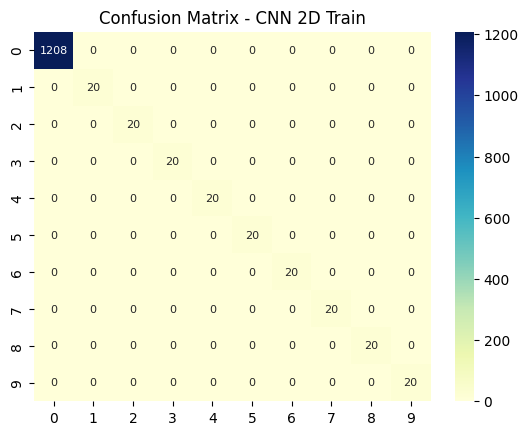

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step


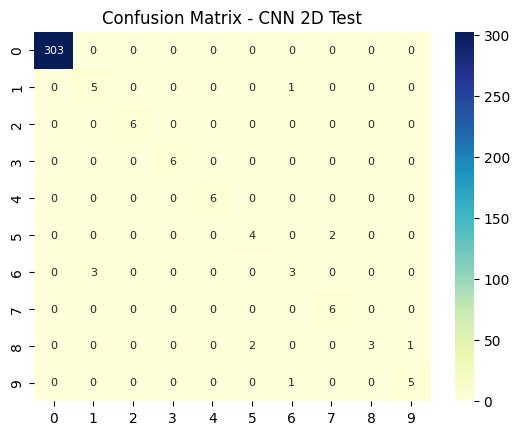

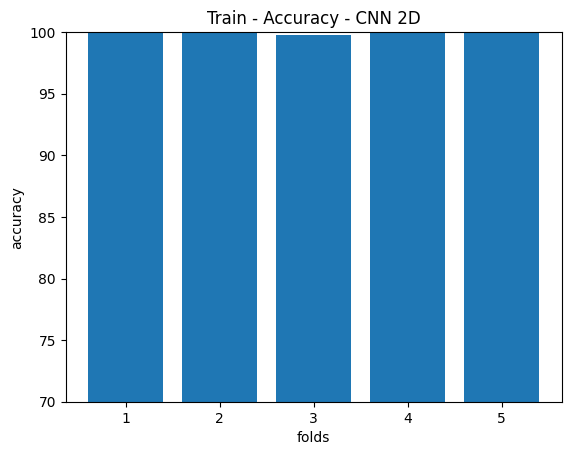

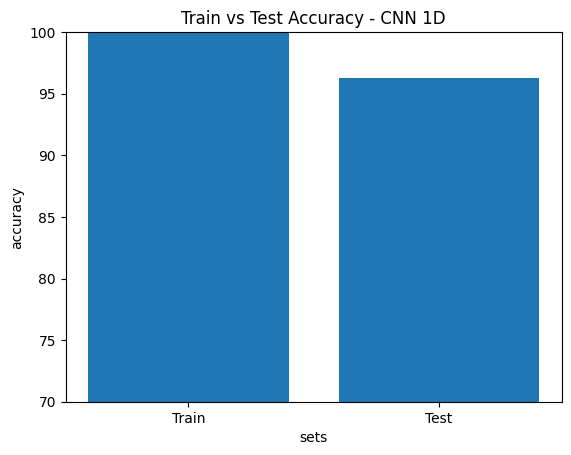

In [11]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_1D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_1D_test) * 100
CNN_2D_train_precision = np.mean(precision_1D) * 100
CNN_2D_test_precision = np.mean(precision_1D_test) * 100
CNN_2D_train_recall = np.mean(recall_1D) * 100
CNN_2D_test_recall = np.mean(recall_1D_test) * 100
CNN_2D_train_f1 = np.mean(f1_1D) * 100
CNN_2D_test_f1 = np.mean(f1_1D_test) * 100
CNN_2D_train_log_loss = np.mean(log_loss_1D)
CNN_2D_test_log_loss = np.mean(log_loss_1D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_1D) * 100  # Average balanced accuracy for train set
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_1D_test) * 100  # Average balanced accuracy for test set

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1-score: {CNN_2D_train_recall:.2f}%")
print(f"Test F1-score: {CNN_2D_test_recall:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

# Confusion Matrix Calculation

def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.predict(X)  # Use Model.model instead of Model
    y_pred = np.argmax(y_pred_proba, axis=1)  # Convert probabilities to class labels
    y_true = np.argmax(y, axis=1)  # Convert one-hot labels to class indices
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 1D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_train, Y_train), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_test, Y_test), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_1D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 1D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()

In [12]:
# Create DataFrame from per-fold metrics
metrics_df = pd.DataFrame({
    'Fold': np.arange(1, kSplits + 1),
    
    'Train Accuracy (%)': np.array(accuracy_1D) * 100,
    'Test Accuracy (%)': np.array(accuracy_1D_test) * 100,

    'Train Precision (%)': np.array(precision_1D) * 100,
    'Test Precision (%)': np.array(precision_1D_test) * 100,

    'Train Recall (%)': np.array(recall_1D) * 100,
    'Test Recall (%)': np.array(recall_1D_test) * 100,

    'Train F1-score (%)': np.array(f1_1D) * 100,
    'Test F1-score (%)': np.array(f1_1D_test) * 100,

    'Train Log Loss': log_loss_1D,
    'Test Log Loss': log_loss_1D_test,

    'Train Balanced Accuracy (%)': np.array(balanced_accuracy_1D) * 100,
    'Test Balanced Accuracy (%)': np.array(balanced_accuracy_1D_test) * 100,
})

metrics_df

,Fold,Train Accuracy (%),Test Accuracy (%),Train Precision (%),Test Precision (%),Train Recall (%),Test Recall (%),Train F1-score (%),Test F1-score (%),Train Log Loss,Test Log Loss,Train Balanced Accuracy (%),Test Balanced Accuracy (%)
0,1,100.00000,96.638655,100.000000,96.590636,100.00000,96.638655,100.000000,96.472939,0.000510,0.118057,100.000,80.000000
1,2,100.00000,96.638655,100.000000,97.425637,100.00000,96.638655,100.000000,96.677440,0.001905,0.104288,100.000,80.000000
2,3,99.72973,94.957983,99.743744,95.010004,99.72973,94.957983,99.729217,94.431451,0.024981,0.114150,98.125,70.000000
3,4,100.00000,96.078431,100.000000,96.689403,100.00000,96.078431,100.000000,95.411893,0.005225,0.087082,100.000,76.666667
4,5,100.00000,97.198880,100.000000,97.436975,100.00000,97.198880,100.000000,97.115210,0.008203,0.073686,100.000,83.333333


In [ ]:
## turn into excel
metrics_df.to_excel(os.path.join(foldername, "Imbalanced_CNN2D_Metrics.xlsx"), index=False)